In [ ]:
import os
from google.colab import files

# 1. Upload do token do Kaggle (selecione o arquivo kaggle.json que você baixou)
if not os.path.exists('/content/kaggle.json'):
    print("Selecione o seu arquivo kaggle.json:")
    files.upload()

# 2. Configura as credenciais no diretório correto
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Baixa o dataset específico da GlobalPay (Credit Card Fraud Detection)
!kaggle datasets download -d mlg-ulb/creditcardfraud

# 4. Descompacta o arquivo silenciosamente
!unzip -q creditcardfraud.zip -d /content/

print("Pronto! O arquivo 'creditcard.csv' já está disponível no ambiente do Colab.")

Selecione o seu arquivo kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 81.2MB/s]

Pronto! O arquivo 'creditcard.csv' já está disponível no ambiente do Colab.


In [ ]:
import pandas as pd
import numpy as np

# Carrega o dataset descompactado
df = pd.read_csv('/content/creditcard.csv')

# Exibe as primeiras linhas para o grupo inspecionar
print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())

# Check do Desbalanceamento (O coração do Explore/Assess)
print("\n--- Distribuição das Classes (0 = Normal, 1 = Fraude) ---")
print(df['Class'].value_counts())
print("\nProporção percentual:")
print(df['Class'].value_counts(normalize=True) * 100)

Dimensões do dataset: (284807, 31)

Primeiras linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Distribuição das Classes (0 = Normal, 1 = Fraude) ---
Class
0    284315
1       492
Name: count, dtype: int64

Proporção percentual:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
from sklearn import model_selection

# Definindo o ponto de corte: 36 horas em segundos (36 * 3600)
limite_tempo_treino = 36 * 3600

# 1. Separação Temporal (OOT)
dados_desenvolvimento = df[df['Time'] <= limite_tempo_treino].copy()
dados_oot = df[df['Time'] > limite_tempo_treino].copy()

print("--- Divisão Temporal (OOT) Concluída ---")
print(f"Dados de Desenvolvimento (Primeiras 36h): {dados_desenvolvimento.shape[0]} transações")
print(f"Dados de Teste OOT (Últimas 12h - O Futuro): {dados_oot.shape[0]} transações")

# 2. Divisão Estratificada de Treino e Validação (Dentro do Desenvolvimento)
features = [col for col in dados_desenvolvimento.columns if col not in ['Class']]
target = 'Class'

X_dev = dados_desenvolvimento[features]
y_dev = dados_desenvolvimento[target]

# Separamos 80% para treino e 20% para validação interna, mantendo a proporção de fraudes
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_dev, y_dev,
    test_size=0.20,
    random_state=42,
    stratify=y_dev
)

# 3. Verificação do desbalanceamento em cada partição gerada
print("\n=== Distribuição de Classes (0 = Normal, 1 = Fraude) ===")
print(f"Desenvolvimento (Total): {dados_desenvolvimento['Class'].sum()} fraudes ({dados_desenvolvimento['Class'].mean()*100:.4f}%)")
print(f"  ├─ Treino (80%): {y_train.sum()} fraudes ({y_train.mean()*100:.4f}%)")
print(f"  └─ Validação (20%): {y_val.sum()} fraudes ({y_val.mean()*100:.4f}%)")
print(f"Teste OOT (Últimas 12h - Futuro): {dados_oot['Class'].sum()} fraudes ({dados_oot['Class'].mean()*100:.4f}%)")

# 4. Salvando o lote OOT como um CSV separado para testar o Streamlit depois!
dados_oot.drop(columns=['Class']).to_csv('clientes_do_dia.csv', index=False)
print("\n[INFO] Arquivo 'clientes_do_dia.csv' gerado com sucesso para simular o upload no Streamlit!")

--- Divisão Temporal (OOT) Concluída ---
Dados de Desenvolvimento (Primeiras 36h): 192232 transações
Dados de Teste OOT (Últimas 12h - O Futuro): 92575 transações

=== Distribuição de Classes (0 = Normal, 1 = Fraude) ===
Desenvolvimento (Total): 377 fraudes (0.1961%)
  ├─ Treino (80%): 302 fraudes (0.1964%)
  └─ Validação (20%): 75 fraudes (0.1951%)
Teste OOT (Últimas 12h - Futuro): 115 fraudes (0.1242%)

[INFO] Arquivo 'clientes_do_dia.csv' gerado com sucesso para simular o upload no Streamlit!


In [ ]:
# %% EXPLORE & MODIFY (E & M)
from sklearn import preprocessing

# 1. EXPLORE: Verificação rápida de valores ausentes (NaN) no treino
missing_values = X_train.isnull().sum().sum()
print(f"Total de valores ausentes no Treino: {missing_values}")

# Visualizando a escala e a assimetria das variáveis brutas frente às PCAs (ex: V1)
print("\nEstatísticas básicas de 'Amount' comparado à variável 'V1' (Treino):")
print(X_train[['Amount', 'V1']].describe().loc[['mean', 'std', 'min', 'max']])

# 2. MODIFY: Escalonamento das variáveis brutas usando RobustScaler
scaler = preprocessing.RobustScaler()

# Criamos cópias para evitar avisos de SettingWithCopyWarning do Pandas
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_oot_scaled = dados_oot[features].copy()

# Ajustamos o escalonador na base de treino e transformamos as demais bases
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val_scaled[['Time', 'Amount']] = scaler.transform(X_val[['Time', 'Amount']])
X_oot_scaled[['Time', 'Amount']] = scaler.transform(dados_oot[['Time', 'Amount']])

print("\n[INFO] Escalonamento das colunas 'Time' e 'Amount' concluído com sucesso.")

Total de valores ausentes no Treino: 0

Estatísticas básicas de 'Amount' comparado à variável 'V1' (Treino):
            Amount         V1
mean     89.022627  -0.117449
std     247.660017   1.875651
min       0.000000 -56.407510
max   19656.530000   2.439207

[INFO] Escalonamento das colunas 'Time' e 'Amount' concluído com sucesso.


Iniciando a busca pela melhor profundidade...

Profundidade:  3 | PR-AUC Treino: 0.7135 | PR-AUC Validação: 0.6398
Profundidade:  5 | PR-AUC Treino: 0.8559 | PR-AUC Validação: 0.7766
Profundidade:  8 | PR-AUC Treino: 0.9530 | PR-AUC Validação: 0.8183
Profundidade: 10 | PR-AUC Treino: 0.9721 | PR-AUC Validação: 0.8169
Profundidade: 12 | PR-AUC Treino: 0.9833 | PR-AUC Validação: 0.8296
Profundidade: 15 | PR-AUC Treino: 0.9973 | PR-AUC Validação: 0.8444
Profundidade: 20 | PR-AUC Treino: 1.0000 | PR-AUC Validação: 0.8372


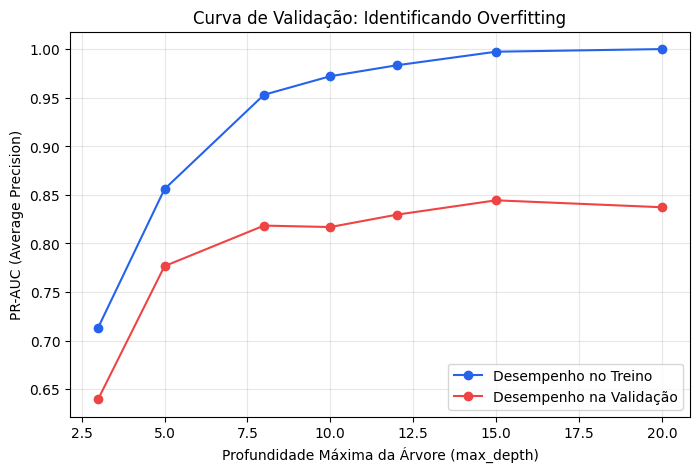

In [ ]:
from sklearn import ensemble, metrics
import matplotlib.pyplot as plt

# Lista de profundidades que queremos testar
profundidades = [3, 5, 8, 10, 12, 15, 20]

historico_treino = []
historico_val = []

print("Iniciando a busca pela melhor profundidade...\n")

for d in profundidades:
    # Criamos o modelo com a profundidade específica do loop
    modelo_teste = ensemble.RandomForestClassifier(
        n_estimators=50,  # Usamos 50 árvores para o teste rodar mais rápido
        max_depth=d,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Treinamos apenas na base de treino escalonada
    modelo_teste.fit(X_train_scaled, y_train)

    # Calculamos as probabilidades para o Treino e para a Validação
    probs_treino = modelo_teste.predict_proba(X_train_scaled)[:, 1]
    probs_val = modelo_teste.predict_proba(X_val_scaled)[:, 1]

    # Avaliamos a métrica PR-AUC (Average Precision)
    pr_auc_treino = metrics.average_precision_score(y_train, probs_treino)
    pr_auc_val = metrics.average_precision_score(y_val, probs_val)

    historico_treino.append(pr_auc_treino)
    historico_val.append(pr_auc_val)

    print(f"Profundidade: {d:2d} | PR-AUC Treino: {pr_auc_treino:.4f} | PR-AUC Validação: {pr_auc_val:.4f}")

# Plotagem do gráfico para análise visual do grupo
plt.figure(figsize=(8, 5))
plt.plot(profundidades, historico_treino, label='Desempenho no Treino', marker='o', color='#2563EB')
plt.plot(profundidades, historico_val, label='Desempenho na Validação', marker='o', color='#EF4444')
plt.xlabel('Profundidade Máxima da Árvore (max_depth)')
plt.ylabel('PR-AUC (Average Precision)')
plt.title('Curva de Validação: Identificando Overfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# %% MODEL (M)
from sklearn import ensemble

print("Iniciando o treinamento do modelo (Random Forest Classifier)...")

# Ajustamos hiperparâmetros básicos para evitar overfitting e controle de tempo de execução
model = ensemble.RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("[INFO] Treinamento do modelo finalizado.")

Iniciando o treinamento do modelo (Random Forest Classifier)...
[INFO] Treinamento do modelo finalizado.


=== Resultados Técnicos ===
PR-AUC na Validação: 0.8179
PR-AUC no Teste OOT: 0.8076

Matriz de Confusão no Teste OOT (Ponto de corte padrão = 0.50):
[[92459     1]
 [   33    82]]

Relatório de Classificação no Teste OOT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     92460
           1       0.99      0.71      0.83       115

    accuracy                           1.00     92575
   macro avg       0.99      0.86      0.91     92575
weighted avg       1.00      1.00      1.00     92575



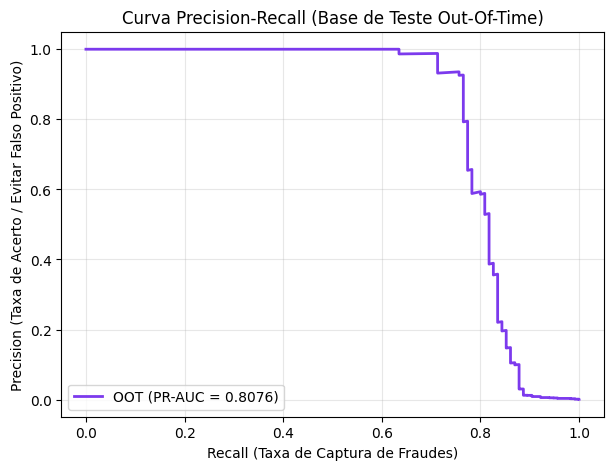

[INFO] Curva Precision-Recall salva como 'curva_pr_oot.png'.


In [ ]:
# %% ASSESS (A) - Avaliação Técnica
from sklearn import metrics
import matplotlib.pyplot as plt

# 1. Obtenção das probabilidades estimadas para a classe positiva (Fraude)
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
y_oot_prob = model.predict_proba(X_oot_scaled)[:, 1]

# Previsões binárias usando o ponto de corte padrão (0.50)
y_val_pred = model.predict(X_val_scaled)
y_oot_pred = model.predict(X_oot_scaled)

# 2. Cálculo das métricas de desempenho
pr_auc_val = metrics.average_precision_score(y_val, y_val_prob)
pr_auc_oot = metrics.average_precision_score(dados_oot[target], y_oot_prob)

print("=== Resultados Técnicos ===")
print(f"PR-AUC na Validação: {pr_auc_val:.4f}")
print(f"PR-AUC no Teste OOT: {pr_auc_oot:.4f}")

# Exibindo a matriz de confusão e o relatório detalhado no OOT (teste cego temporal)
print("\nMatriz de Confusão no Teste OOT (Ponto de corte padrão = 0.50):")
print(metrics.confusion_matrix(dados_oot[target], y_oot_pred))

print("\nRelatório de Classificação no Teste OOT:")
print(metrics.classification_report(dados_oot[target], y_oot_pred))

# 3. Geração e salvamento do gráfico de Precision-Recall no OOT
precision, recall, _ = metrics.precision_recall_curve(dados_oot[target], y_oot_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"OOT (PR-AUC = {pr_auc_oot:.4f})", color='#7C3AED', lw=2)
plt.xlabel("Recall (Taxa de Captura de Fraudes)")
plt.ylabel("Precision (Taxa de Acerto / Evitar Falso Positivo)")
plt.title("Curva Precision-Recall (Base de Teste Out-Of-Time)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('curva_pr_oot.png', dpi=300)
plt.show()
print("[INFO] Curva Precision-Recall salva como 'curva_pr_oot.png'.")

In [ ]:
# %% ASSESS FINANCEIRO (Tradução para Negócio)

def avaliar_retorno_financeiro(y_true, y_prob, threshold=0.50, custo_fn=150.0, custo_fp=10.0):
    # Aplica o threshold de decisão definido para as predições
    preds = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix(y_true, preds).ravel()

    # Baseline: se não tivéssemos modelo, aprovaríamos todas as transações.
    # Toda fraude existente seria perda financeira (Falso Negativo).
    total_fraudes = fn + tp
    perda_baseline = total_fraudes * custo_fn

    # Com o modelo implementado
    perda_modelo = (fn * custo_fn) + (fp * custo_fp)
    economia_gerada = perda_baseline - perda_modelo

    taxa_captura = (tp / total_fraudes) * 100
    taxa_abordagem = ((fp + tp) / len(y_true)) * 100

    print(f"\n--- Simulação Financeira para o Threshold de {threshold*100:.0f}% ---")
    print(f"Taxa de Captura (Recall): {taxa_captura:.2f}% de todas as fraudes")
    print(f"Porcentagem de transações que exigirão revisão/bloqueio: {taxa_abordagem:.2f}% da base")
    print(f"Prejuízo projetado SEM modelo: R$ {perda_baseline:,.2f}")
    print(f"Prejuízo projetado COM modelo: R$ {perda_modelo:,.2f}")
    print(f"Economia gerada para a GlobalPay: R$ {economia_gerada:,.2f}")

# Simulação com diferentes níveis de tolerância ao risco para análise de negócio
avaliar_retorno_financeiro(dados_oot[target], y_oot_prob, threshold=0.50)
avaliar_retorno_financeiro(dados_oot[target], y_oot_prob, threshold=0.20)


--- Simulação Financeira para o Threshold de 50% ---
Taxa de Captura (Recall): 71.30% de todas as fraudes
Porcentagem de transações que exigirão revisão/bloqueio: 0.09% da base
Prejuízo projetado SEM modelo: R$ 17,250.00
Prejuízo projetado COM modelo: R$ 4,960.00
Economia gerada para a GlobalPay: R$ 12,290.00

--- Simulação Financeira para o Threshold de 20% ---
Taxa de Captura (Recall): 77.39% de todas as fraudes
Porcentagem de transações que exigirão revisão/bloqueio: 0.13% da base
Prejuízo projetado SEM modelo: R$ 17,250.00
Prejuízo projetado COM modelo: R$ 4,240.00
Economia gerada para a GlobalPay: R$ 13,010.00


In [12]:
import joblib
import pickle

# Opção 1: Usando joblib (Mais recomendado para modelos pesados como Random Forest/XGBoost)
joblib.dump(model, 'modelo_antifraude_v1.pkl')

# Opção 2: Usando a biblioteca padrão pickle
with open('modelo_antifraude_v1.pkl', 'wb') as arquivo:
    pickle.dump(model, arquivo)

print("Modelo salvo com sucesso no formato .pkl!")

Modelo salvo com sucesso no formato .pkl!
